In [9]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [10]:
(X_train,y_train) , (X_test,y_test) = keras.datasets.mnist.load_data()

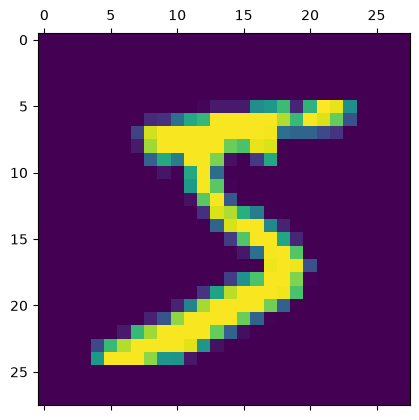

In [11]:
plt.matshow(X_train[0])

In [12]:
#scaling data to get better outcome
X_train =X_train/255
X_test =X_test/255

In [13]:
#converting 2d array to 1d
X_train_flatten =X_train.reshape(len(X_train),28*28)
X_test_flatten =X_test.reshape(len(X_test),28*28)

In [14]:
#X_train_flatten.shape
X_test_flatten.shape

(10000, 784)

In [24]:
model =keras.Sequential([
    keras.Input(shape=(784,)),
    keras.layers.Dense(10,activation ='sigmoid' )
])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
               metrics=['accuracy']
)
model.fit(X_train_flatten,y_train,epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 416us/step - accuracy: 0.8749 - loss: 0.4738
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 410us/step - accuracy: 0.9151 - loss: 0.3047
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 411us/step - accuracy: 0.9205 - loss: 0.2833
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 411us/step - accuracy: 0.9242 - loss: 0.2733
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 411us/step - accuracy: 0.9249 - loss: 0.2668


In [25]:
model.evaluate(X_test_flatten,y_test)#92%

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 399us/step - accuracy: 0.9269 - loss: 0.2656


[0.2656186819076538, 0.9269000291824341]

In [26]:
y_predict=model.predict(X_test_flatten)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 283us/step


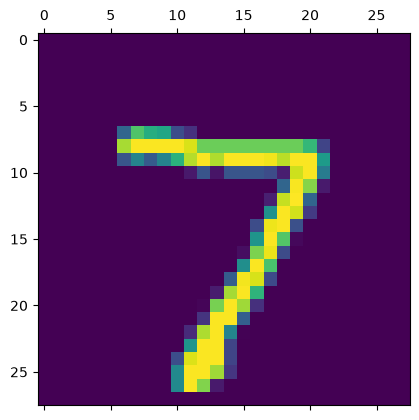

In [28]:
#first handwritten digit
plt.matshow(X_test_flatten[0].reshape(28,28))

In [29]:
#predicting it
y_predict[0]

array([1.62381679e-02, 3.88226084e-07, 1.35021999e-01, 9.66588318e-01,
       2.34093680e-03, 1.15837954e-01, 1.82747590e-06, 9.99812126e-01,
       1.00172907e-01, 6.63950861e-01], dtype=float32)

In [20]:
np.argmax(y_predict[0])

np.int64(7)

In [21]:
y_predict_labels=[np.argmax(i) for i in y_predict]

In [30]:
#confusion matrix
cm=tf.math.confusion_matrix(labels=y_test,predictions=y_predict_labels)
cm

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 964,    0,    1,    2,    0,    5,    6,    1,    1,    0],
       [   0, 1118,    3,    2,    0,    1,    4,    2,    5,    0],
       [   5,    9,  926,   17,   10,    3,   12,    9,   37,    4],
       [   1,    0,   20,  942,    1,   12,    2,    7,   16,    9],
       [   2,    2,    4,    2,  932,    0,    9,    3,    6,   22],
       [  10,    3,    2,   47,   12,  764,   18,    4,   27,    5],
       [  10,    3,    8,    1,    8,   12,  911,    2,    3,    0],
       [   1,    8,   21,   10,   12,    1,    0,  937,    1,   37],
       [   7,   11,    6,   34,   10,   26,    8,    9,  856,    7],
       [  11,    7,    1,   14,   44,    6,    0,   21,    4,  901]],
      dtype=int32)>

Text(95.83333333333333, 0.5, 'Truth')

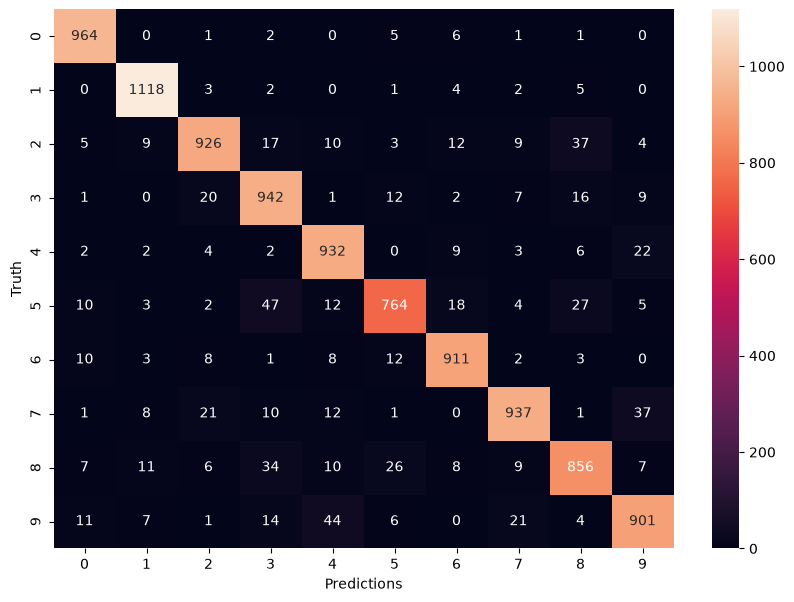

In [31]:
import seaborn as sn
plt.figure(figsize=(10,7))
sn.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Predictions')
plt.ylabel('Truth')

In [44]:
#model with 1 hidden layer using keras inbuilt flatten for my 2d array
hidden_layer_model =keras.Sequential([
    keras.Input(shape=(28,28)),
    keras.layers.Flatten(),
    keras.layers.Dense(100,activation ='relu' ),
    keras.layers.Dense(10,activation ='sigmoid' )
])
hidden_layer_model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
               metrics=['accuracy']
)
hidden_layer_model.fit(X_train,y_train,epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 711us/step - accuracy: 0.9216 - loss: 0.2735
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 705us/step - accuracy: 0.9631 - loss: 0.1243
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 699us/step - accuracy: 0.9737 - loss: 0.0876
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 702us/step - accuracy: 0.9807 - loss: 0.0646
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 704us/step - accuracy: 0.9838 - loss: 0.0518


In [45]:
hidden_layer_model.evaluate(X_test,y_test)#97%

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 453us/step - accuracy: 0.9735 - loss: 0.0868


[0.08683519065380096, 0.9735000133514404]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 357us/step


Text(95.83333333333333, 0.5, 'Truth')

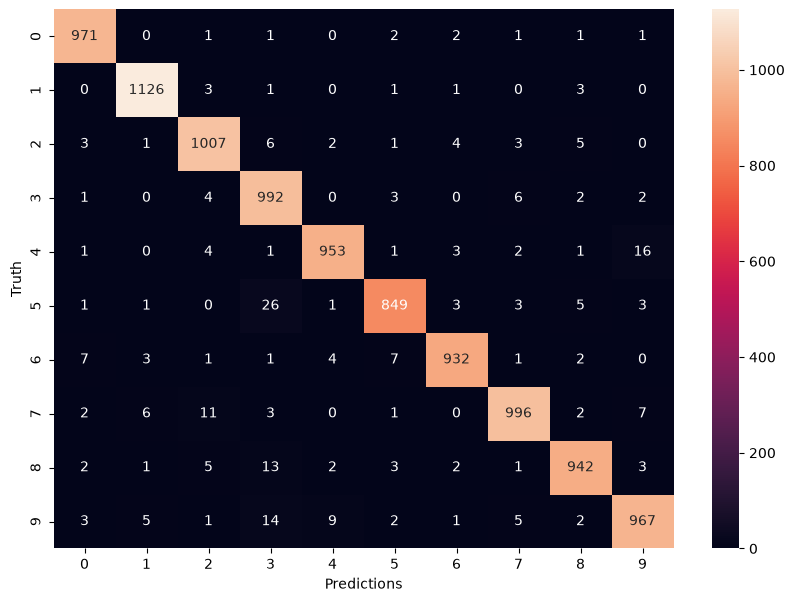

In [46]:
y_predict_2 = hidden_layer_model.predict(X_test)
y_predict_labels_2 =  [np.argmax(i) for i in y_predict_2]
                       
cm_2 = tf.math.confusion_matrix(labels =y_test,predictions = y_predict_labels_2)
plt.figure(figsize=(10,7))
sn.heatmap(cm_2,annot=True,fmt='d')
plt.xlabel('Predictions')
plt.ylabel('Truth')